In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout
from tensorflow.keras.callbacks import EarlyStopping 
from tensorflow.keras.regularizers import l2

In [3]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [4]:
df.shape


(768, 9)

In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [8]:
# Separate X and Y

X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
# Feature Scaling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)

print("X_train empty:", X_train.size == 0)
print("y_train empty:", y_train.size == 0)

X_train shape: (614, 8)
y_train shape: (614,)
X_train dtype: float64
y_train dtype: int64
X_train empty: False
y_train empty: False


In [40]:
X_train = np.asarray(X_train).astype("float32")
X_test = np.asarray(X_test).astype("float32")

y_train = np.asarray(y_train).astype("float32")
y_test = np.asarray(y_test).astype("float32")

In [46]:
# Build ANN (Artificial Neural Network)  

model = Sequential()

model.add(
    Dense(
        16,
        activation="relu",
        input_shape=(X_train.shape[1],),
        kernel_regularizer=l2(0.001)
    )
)

model.add(Dropout(0.2))

model.add(Dense(8, activation="relu"))

model.add(Dropout(0.2))

model.add(Dense(1, activation="sigmoid"))


C:\Users\NAVTESH\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
# Compile

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [48]:
# Early Stopping .... This prevents unnecessary training when validation loss stops improving .

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)



In [49]:
# Train

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6680 - loss: 0.6796 - val_accuracy: 0.6423 - val_loss: 0.6451
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6782 - loss: 0.6284 - val_accuracy: 0.6504 - val_loss: 0.6171
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6721 - loss: 0.6051 - val_accuracy: 0.6585 - val_loss: 0.5945
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6782 - loss: 0.5918 - val_accuracy: 0.6504 - val_loss: 0.5738
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6619 - loss: 0.5687 - val_accuracy: 0.6423 - val_loss: 0.5557
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6904 - loss: 0.5545 - val_accuracy: 0.6423 - val_loss: 0.5412
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6762 - loss: 0.5384 - val_accuracy: 0.6423 - val_loss: 0.5273
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6864 - loss: 0.5236 - val_accuracy: 0.

In [50]:
# Prediction

y_pred_prob = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [51]:
# Convert probabilities into 0/1

y_pred = (y_pred_prob > 0.5).astype(int)

In [62]:
from sklearn.metrics import accuracy_score, confusion_matrix , classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print('Confustion Matrix :',cm)

print('Classification_Report :',classification_report(y_test, y_pred))


Accuracy: 0.8181818181818182
Confustion Matrix : [[83 16]
 [12 43]]
Classification_Report :               precision    recall  f1-score   support

         0.0       0.87      0.84      0.86        99
         1.0       0.73      0.78      0.75        55

    accuracy                           0.82       154
   macro avg       0.80      0.81      0.81       154
weighted avg       0.82      0.82      0.82       154



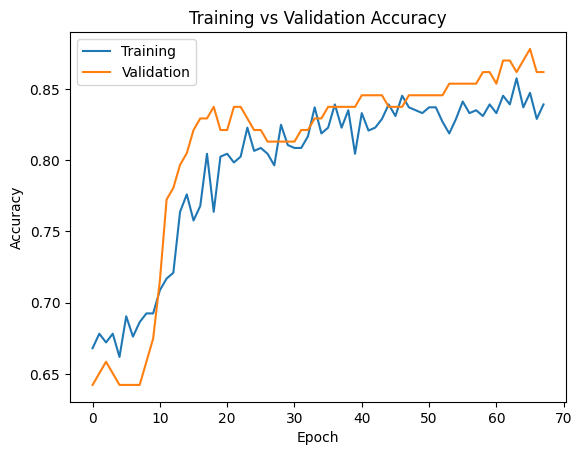

In [64]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(["Training", "Validation"])
plt.show()

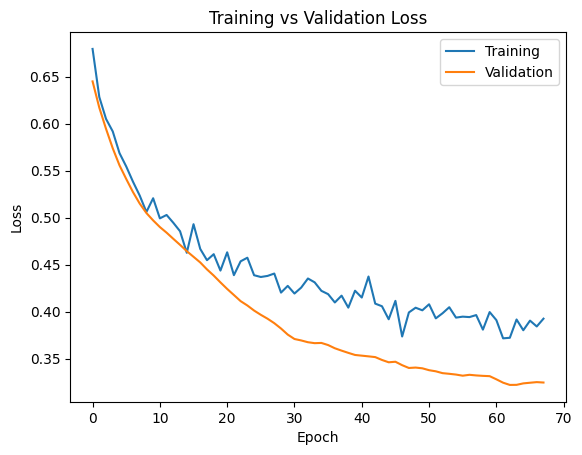

In [65]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(["Training", "Validation"])
plt.show()